<a href="https://colab.research.google.com/github/AncaraniJuanDiego/IAModelosDeRegresi-n./blob/main/California_Housting(TP1_IA).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Trabajo Practico numero 1: Inteligencia artificial y modelos de regresión.**

Narrativa:

*   Dataset que trata sobre datos censales en familias y sus viviendas en estados unidos en los años 90, especificamente sobre block grupales.
*   Formato tabular: +20.000 registros censales.
*   8 variables predictivas.

In [ ]:
#1. Estructura sugerida para el código
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt           #4 librerias fundamentales para cualquier trabajo hecho por un cientifico de datos.
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge


# **Parte 1: Exploración y Preprocesamiento**

Carga y descripción inicial

      1. Cargar el dataset usando fetch_california_housing(as_frame=True).
      2. Reportar: dimensiones, tipos de datos, valores faltantes.
      3. Generar estadísticas descriptivas (describe()) para todas las variables.

In [ ]:
from sklearn.datasets import fetch_california_housing #para cargar el dataset

Análisis de distribuciones

    1. Graficar histogramas de al menos 4 variables de interés.
    2. Identificar outliers.

In [ ]:
# 1. Carga
data = fetch_california_housing(as_frame=True)
df = data.frame

In [ ]:
df

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422
...,...,...,...,...,...,...,...,...,...
20635,1.5603,25.0,5.045455,1.133333,845.0,2.560606,39.48,-121.09,0.781
20636,2.5568,18.0,6.114035,1.315789,356.0,3.122807,39.49,-121.21,0.771
20637,1.7000,17.0,5.205543,1.120092,1007.0,2.325635,39.43,-121.22,0.923
20638,1.8672,18.0,5.329513,1.171920,741.0,2.123209,39.43,-121.32,0.847


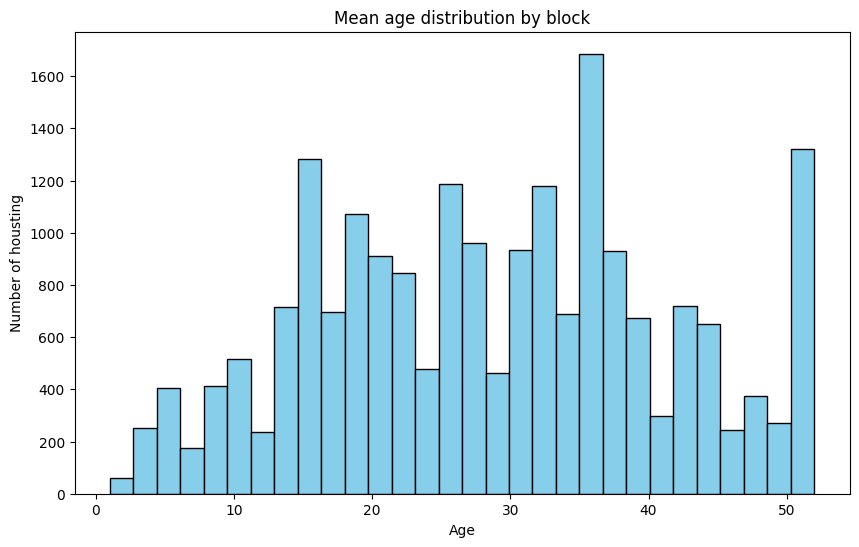

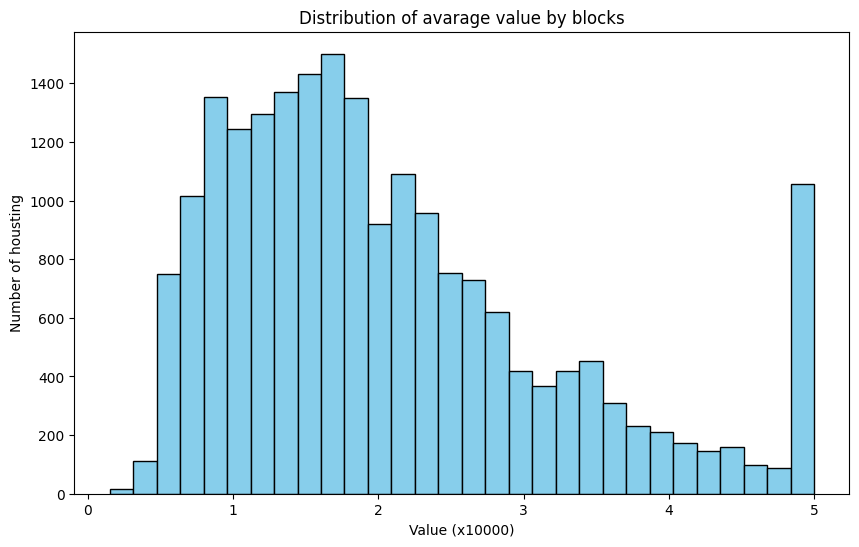

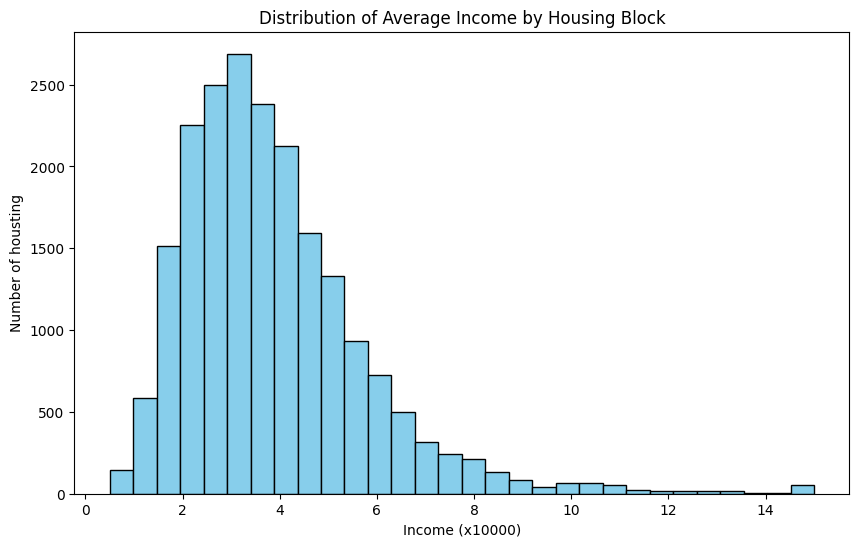

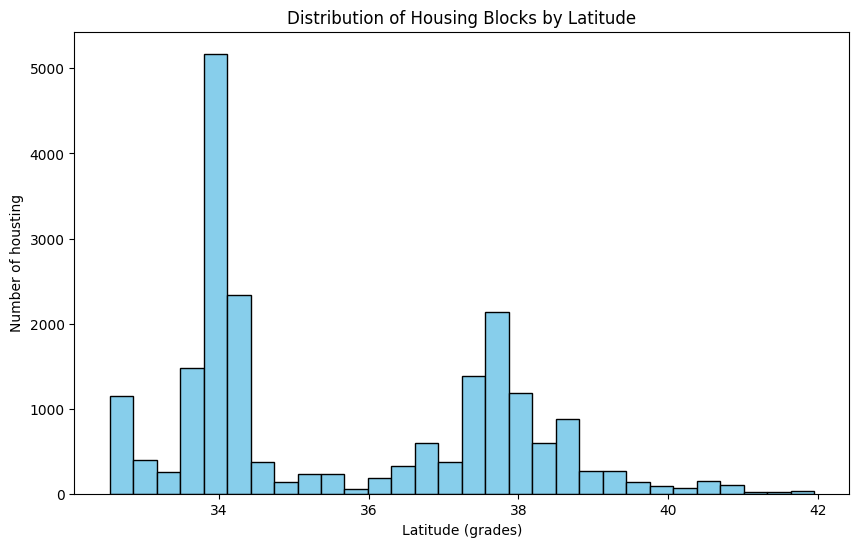

In [ ]:
#Histograma 1: Distribuciòn de edades promedio x cantidad de personas.

Age_zone = df['HouseAge']
plt.figure(figsize=(10, 6))
plt.hist(Age_zone, bins=30, color= 'SkyBlue', edgecolor = 'black')
plt.title('Mean age distribution by block')
plt.xlabel('Age')
plt.ylabel('Number of housting')
plt.show()

#Histograma 2: Distribuciòn del valor medio x cantidad de viviendas.

House_val = df['MedHouseVal']
plt.figure(figsize=(10,6))
plt.hist(House_val, bins=30, color= 'SkyBlue', edgecolor = 'black')
plt.title('Distribution of avarage value by blocks')
plt.xlabel('Value (x10000)')
plt.ylabel('Number of housting')
plt.show()

#Histograma 3: Distribuciòn de ingreso medio x cantidad de viviendas.

Income = df['MedInc']
plt.figure(figsize=(10,6))
plt.hist(Income, bins=30, color= 'SkyBlue', edgecolor = 'black')
plt.title('Distribution of Average Income by Housing Block')
plt.xlabel('Income (x10000)')
plt.ylabel('Number of housting')
plt.show()

#Histograma 4: Distribuciòn de cantidad de dormitorios x vivienda

Latitude_block = df['Latitude']
plt.figure(figsize=(10,6))
plt.hist(Latitude_block, bins=30, color= 'SkyBlue', edgecolor = 'black')
plt.title('Distribution of Housing Blocks by Latitude')
plt.xlabel('Latitude (grades)')
plt.ylabel('Number of housting')
plt.show()

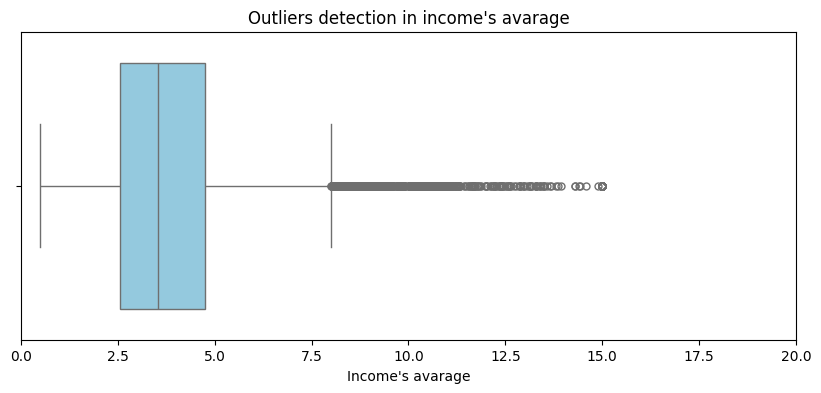

Report of outliers: 
Lower limit detected +:-0.71
Upper limit detected: 8.01
Total count of outliers: 681

 First 20 outliers detected:
[ 8.3252  8.3014 11.6017  8.2049  8.401   8.317   8.1564  8.8793  8.8342
 10.0825  9.3959 11.8603 13.499  12.2138  8.1872 12.3804  8.1194  8.7477
  8.3996  8.4045]
------------------------------


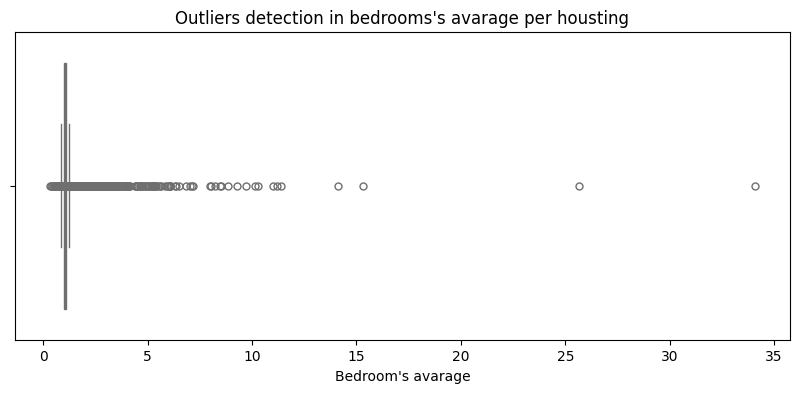

Report of outliers:
Lower limit detected:0.87
Upper limit detected 1.24
Total count of outliers: 1424

 First 20 outliers detected:
[1.24899598 1.37295082 0.75438596 1.26086957 1.55737705 1.49056604
 1.36842105 1.65986395 1.32926829 1.34210526 0.57142857 1.24347826
 1.33404711 0.73076923 1.30363036 0.78181818 0.84444444 1.26277372
 0.65957447 1.50318471]
------------------------------


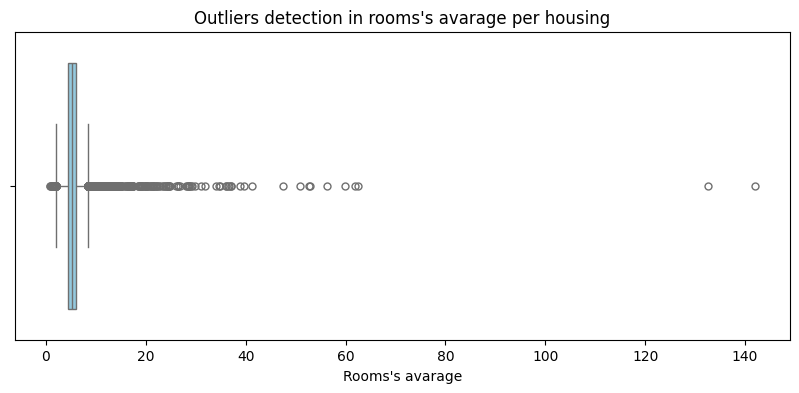

Report of outliers:
Lower limit detected:2.02
Upper limit detected: 8.47
Total count of outliers: 511

 First 20 outliers detected:
[ 1.71428571  8.97286822  8.92835821  9.21022727  9.1227154   9.
  8.51824818  8.97368421 10.51530612 29.85294118  8.62530414 10.16859122
 31.77777778 16.84753363 28.75728155 13.47303922 11.49086162  9.79302832
 28.11290323 33.98969072]
------------------------------


In [ ]:

#Ingresos

plt.figure(figsize=(10, 4))
sns.boxplot(x=df['MedInc'], color='SkyBlue', fliersize=5)
plt.xlim(0,20)
plt.axvline(x=-0.71, color='red', linestyle = '--', label='Lower limit in label x')
plt.title("Outliers detection in income's avarage")
plt.xlabel("Income's avarage")
plt.show()

Q1 = df['MedInc'].quantile(0.25)
Q3 = df['MedInc'].quantile(0.75)
interquartile_range= Q3 - Q1

Lower_limit = Q1 - 1.5*interquartile_range
Upper_limit = Q3 + 1.5*interquartile_range

outliers = df[(df['MedInc'] < Lower_limit) | (df['MedInc'] > Upper_limit)]


print(f"Report of outliers: ")
print(f"Lower limit detected:{Lower_limit:.2f}")
print(f"Upper limit detected: {Upper_limit:.2f}")
print(f"Total count of outliers: {len(outliers)}")
print("\n First 20 outliers detected:")
print(outliers['MedInc'].head(20).values)
print("-" * 30)

#Los bigotes representan el rango en el que se encuentra la gran mayoría de tus datos. Técnicamente, se extienden hasta el valor máximo y mínimo que no sean considerados atípicos.
#Si se detecta una valor mayor o menos a los limites centrales (upper y lower limit) se coinsidera 'outlier'.

#Dormitorios
plt.figure(figsize=(10, 4))
sns.boxplot(x=df['AveBedrms'], color='SkyBlue', fliersize=5)
plt.title("Outliers detection in bedrooms's avarage per housting")
plt.xlabel("Bedroom's avarage")
plt.show()

Q1 = df['AveBedrms'].quantile(0.25)
Q3 = df['AveBedrms'].quantile(0.75)
interquartile_range= Q3 - Q1


Lower_limit = Q1 - 1.5*interquartile_range
Upper_limit = Q3 + 1.5*interquartile_range

outliers = df[(df['AveBedrms'] < Lower_limit) | (df['AveBedrms'] > Upper_limit)]


print(f"Report of outliers:")
print(f'Lower limit detected:{Lower_limit:.2f}')
print(f"Upper limit detected {Upper_limit:.2f}")
print(f"Total count of outliers: {len(outliers)}")
print("\n First 20 outliers detected:")
print(outliers['AveBedrms'].head(20).values)
print("-" * 30)

#Habitaciones

plt.figure(figsize=(10, 4))
sns.boxplot(x=df['AveRooms'], color='SkyBlue', fliersize=5)
plt.title("Outliers detection in rooms's avarage per housing")
plt.xlabel("Rooms's avarage")
plt.show()

Q1 = df['AveRooms'].quantile(0.25)
Q3 = df['AveRooms'].quantile(0.75)
interquartile_range= Q3 - Q1


Lower_limit = Q1 - 1.5*interquartile_range
Upper_limit = Q3 + 1.5*interquartile_range

outliers = df[(df['AveRooms'] < Lower_limit) | (df['AveRooms'] > Upper_limit)]


print(f"Report of outliers:")
print(f'Lower limit detected:{Lower_limit:.2f}')
print(f"Upper limit detected: {Upper_limit:.2f}")
print(f"Total count of outliers: {len(outliers)}")
print("\n First 20 outliers detected:")
print(outliers['AveRooms'].head(20).values)
print("-" * 30)


**Escalado de características**

      1. Aplicar StandardScaler a las features numéricas
      2. Explicar por qué es necesario escalar antes de entrenar un modelo lineal
      3. Importante: Ajustar el scaler solo con el conjunto de entrenamiento

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

Es necesario aplicar estandarización para no confundir al modelo con las variables al entrenarlas, debido a que tienen diferentes rangos de longitud, dado que algunas eran mas extensas que otras. Hicimos un 'centroide' o 'reajuste' respectivamente.

¿Que estamos prediciendo con este modelo predictivo?

 * Relación matematica (score) de que cada 100 bloques, conociendo su precio medio, analice cuales son caros y baratos.

In [ ]:
# 1. Definir la variable objetivo (Y) y las características (X) ANTES de escalar.
umbral = df['MedHouseVal'].median()
Y = (df['MedHouseVal'] > umbral).astype(int)
X = df.drop('MedHouseVal', axis=1)

# 2. Dividir en entrenamiento y prueba.
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

# Función para abrir escalación.
scaler = StandardScaler()

# Ajustamos con X_train y transformamos ambos.
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Crear, ajustar y evaluar el modelo
modelo = LogisticRegression()
modelo.fit(X_train_scaled, Y_train) # Entrenamos con TRAIN, no con Test.

print(f"Precisión en Test: {modelo.score(X_test_scaled, Y_test):.4f}")

Y   #Si supera el umbral, se le asigna 1.. Todos los resultados son según lo predicho x el modelo.


Precisión en Test: 0.8261


,MedHouseVal
0,1
1,1
2,1
3,1
4,1
...,...
20635,0
20636,0
20637,0
20638,0




* El modelo predictivo analiza que: cada 100 bloques, el  82% coinsiden con lo que dice el modelo (predice correctamente entre caro y barato). Hay 18 bloques que estan analizados incorrectamente, debido a que el dataframe aun tiene falta de información.

Ejemplos:
* Un barrio con ingreso medio, puede tener una mala ubicación.
* Un barrio con muchos habitantes, con buena ubicación.



# **Parte 2: Ingenieria de Features**

* Consigna principal:  Crear dos nuevas variables derivadas que, desde tu perspectiva, podrían mejorar la capacidad predictiva del modelo para estimar el valor de las viviendas.

✅ Fundamentación teórica: Explicar por qué esta variable podría ser relevante para predecir precios de vivienda, basándote en conocimiento del dominio (economía urbana, geografía, sociología, etc.)

✅ Implementación técnica: Código claro y reproducible que genere la nueva variable a partir de las originales

In [ ]:
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

In [ ]:
df['rooms_per_Bedroom'] = df['AveRooms'] / df['AveBedrms'].replace(0, np.nan) #('habitaciones por dormitorios').
df['Income_per_person'] = df['MedInc'] / df['AveOccup'] #('ingreso por persona'). x 10

In [ ]:
df = df.dropna()

# Definir X e y
X = df.drop('MedHouseVal', axis=1)
y = df['MedHouseVal']

# División
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Escalado
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Modelo Lineal (Predicción de valor continuo)
modelo = LinearRegression()
modelo.fit(X_train_scaled, y_train)

y_pred = modelo.predict(X_test_scaled)
print(f'R-squared en el test: {r2_score(y_test, y_pred):.4f}')

R-squared en el test: 0.6578


el 65% → El modelo utiliza las variables originales + las nuevas que se han creado, sin embargo solo pueden explicar el 65% de la variabilidad del valor medio del bloque. Cuando sucede esto, es común que haya variables que no se incluyeron originalmente, como: Calidad de materiales de construcción- cercania al centro- vistas cercanas- ect.

In [ ]:
df

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal,rooms_per_Bedroom,Income_per_person
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526,6.821705,3.257687
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585,6.418626,3.934608
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521,7.721053,2.589838
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413,5.421277,2.214765
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422,5.810714,1.763125
...,...,...,...,...,...,...,...,...,...,...,...
20635,1.5603,25.0,5.045455,1.133333,845.0,2.560606,39.48,-121.09,0.781,4.451872,0.609348
20636,2.5568,18.0,6.114035,1.315789,356.0,3.122807,39.49,-121.21,0.771,4.646667,0.818751
20637,1.7000,17.0,5.205543,1.120092,1007.0,2.325635,39.43,-121.22,0.923,4.647423,0.730983
20638,1.8672,18.0,5.329513,1.171920,741.0,2.123209,39.43,-121.32,0.847,4.547677,0.879423


# **Parte 3: Modelado e Interpretación**

In [ ]:
#modelo a- features originales.
Original_features = ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']
X_a = df[Original_features]

#modelo b- features orig + agregadas.

Add_features= ['rooms_per_Bedroom', 'Income_per_person']
X_b = df[Original_features + Add_features]

y= df['MedHouseVal']

#función para entrenar, escalar y evaluar.

def complete_evaluated(X, y, name):
  X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

  #escalado
  scaler = StandardScaler()
  X_train_scaled = scaler.fit_transform(X_train)
  X_test_scaled = scaler.transform(X_test)

  #entrenar
  model = LinearRegression()
  model.fit(X_train_scaled, y_train)

  #predecir
  y_pred = model.predict(X_test_scaled)

  #Matrices
  r2 = r2_score(y_test, y_pred)
  rmse = np.sqrt(mean_squared_error(y_test, y_pred))
  mae = mean_absolute_error(y_test, y_pred)

  return {'Modelo': name, 'R2_Score': r2, 'RMSE': rmse, 'MAE': mae}

#resultados sobre matrices originales vs agregadas...

results = []
results.append(complete_evaluated(X_a, y, 'Original_features'))
results.append(complete_evaluated(X_b, y, 'Add_features'))

df_results = pd.DataFrame(results)
display(df_results)

,Modelo,R2_Score,RMSE,MAE
0,Original_features,0.575788,0.745581,0.533200
1,Add_features,0.657820,0.669623,0.481234


**Interpretaciòn de mètricas:** ¿Que cambia respecto a las features originales?

1. R² (score).

Se logra explicar +8% mas de la variabilidad de precios de bloques,  con ayuda de las variables agregadas.

2. RMSE (error cuadratico medio)

Se redujo el impacto de errores grandes al predecir, pasando del 74% de cometer, al 66%. Lo que convierte al modelo, mas estable.

3. MAE (error absoluto medio)

Baja de 0.53 a 0.48. Lo que indica que en promedio, tus predicciones ahora están unos $5,200 dólares más cerca de la realidad que antes. El modelo se equivoca x 48k dolares.





2. Interpretacion de coeficientes

* Para el modelo con las features ingenierizadas:

      1. Listar todos los coeficientes ordenados por valor absoluto.
      2. Seleccionar 3 coeficientes (incluyendo al menos 1 de tus nuevas features) y explicar:
    * "Un aumento de 1 unidad en [feature], manteniendo constantes las demás variables, se asocia con un cambio de [coeficiente] unidades en el valor mediano de vivienda, es decir, aproximadamente [coeficiente * 100,000] dólares."

* Discutir: ¿El signo del coeficiente coincide con tu expectativa teórica? ¿Por qué sí/no?



* MedInc: "Un aumento de una unidad en 'MedInc' menteniendo constantes las otras variables, se asocia con un cambio de 8.32 unidades en el valor medio de viviendas. Es decir, aproximadamente 832.100 USD.

* MedHouseVal: "Un aumento de una unidad en 'MedHouseVal' menteniendo constantes las otras variables, se asocia con un cambio de 4.52 unidades en el valor medio de viviendas. Es decir, aproximadamente 452.100 USD.


* Income_per_person: Un aumento de 1 unidad estándar en 'Income_per_person', manteniendo constantes las demás variables, se asocia con un cambio de 3.25 unidades en el valor mediano de vivienda, es decir, aproximadamente $325.000 dólares.


3. Análisis de impacto de las nuevas features

* Comparar métricas entre modelo base y modelo extendido
* ¿Mejoró la capacidad predictiva? ¿En train? ¿En test? (discutir sobreajuste)
* Usar permutation_importance o análisis de correlación parcial para evaluar contribución real de tus nuevas variables

In [ ]:
from sklearn.inspection import permutation_importance

In [ ]:
result = permutation_importance(modelo, X_test_scaled, y_test, n_repeats=10,  random_state= 10)

importance_df = pd.DataFrame({
    'Feature': X_b.columns,
    'Mean_importance': result.importances_mean,
    'Std_importance': result.importances_std
})

importance_df = importance_df.sort_values(by = 'Mean_importance' , ascending= False).reset_index(drop=True)
importance_df = importance_df.sort_values(by = 'Std_importance', ascending= False).reset_index(drop=True)
#Ranking

print('Ranking values most importants in descending order: ')
print('--' * 60)
print(importance_df[['Feature', 'Mean_importance', 'Std_importance']])

Ranking values most importants in descending order: 
------------------------------------------------------------------------------------------------------------------------
             Feature  Mean_importance  Std_importance
0          Longitude         1.016350        0.022002
1           Latitude         1.203912        0.014195
2  Income_per_person         0.629183        0.011997
3             MedInc         0.054870        0.002896
4           AveRooms         0.051227        0.002201
5  rooms_per_Bedroom         0.046696        0.001884
6          AveBedrms         0.025695        0.001308
7           HouseAge         0.021857        0.001299
8         Population         0.002581        0.000602
9           AveOccup         0.000029        0.000009


* En la comparación de métricas entre el modelo base y el agregado, la predicción mejora coinsiderablemente, con un 8% mas de efectividad. Con el hecho de agregar 2 variables mas, es un avance fuerte. Esto indica que: 'el ingreso por persona' con un nivel de score = 0.62, la hace una variable muy importante para predecir. Ademas, al saber el ingreso individual, el modelo predice mejor que con el ingreso medio de cada vivienda.

* Las variables mas importantes aparecen en el df original ('Longitude', 'latitude') con 1.01 y 1.20 respectivamente. Esto analiza, que sabiendo la locación y densidad de cada zona, es posible adelantar mejor cuanto sera el costo total de viviendas.

* Validación de supuestos (bonus)

      1. Graficar residuos vs. valores predichos: ¿hay patrones?
      2. Verificar normalidad de residuos (QQ-plot)
      3. Comentar brevemente si los supuestos de regresión lineal se cumplen razonablemente

In [ ]:
import scipy.stats as stats

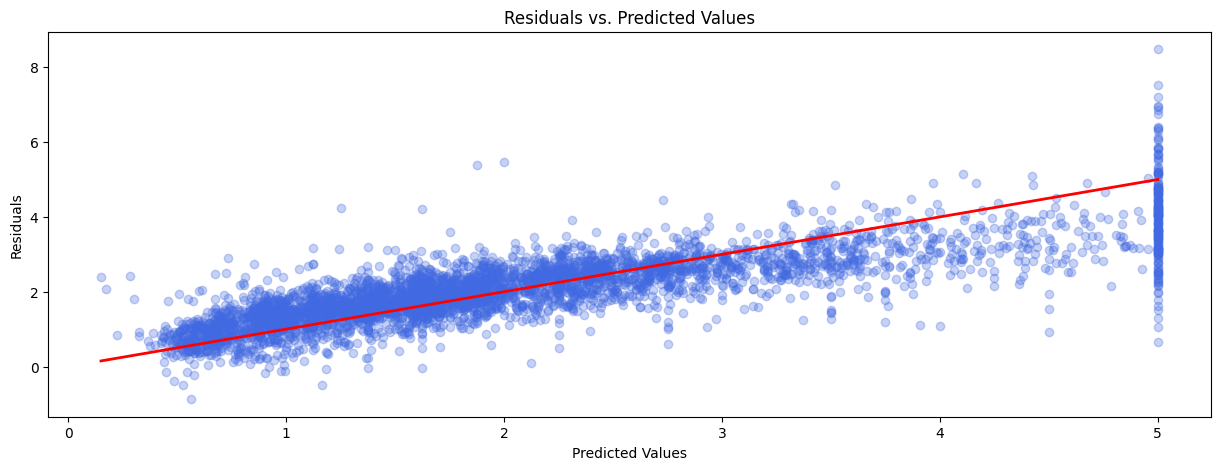

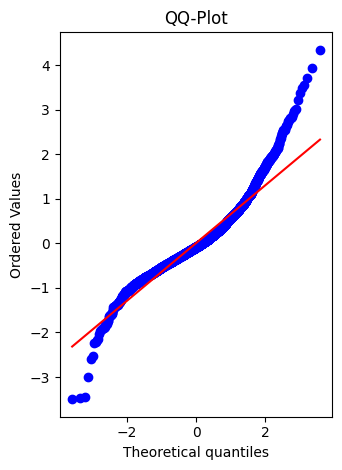

In [ ]:
residuals = y_test - y_pred

plt.figure(figsize=(15, 5))

#Grafico 1: Residuos vs Predichos (homocedasticidad)

plt.scatter(y_test, y_pred, alpha = 0.3, color=  'royalblue', label='Predicciones del Modelo')

#linea de referencia
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', lw=2, label='Línea de Perfección')
plt.title('Residuals vs. Predicted Values')
plt.xlabel('Predicted Values')
plt.ylabel('Residuals')
plt.show()

#Grafico 2: QQ-Plto (Normalidad)

plt.subplot(1,2,2)
stats.probplot(residuals, dist= 'norm', plot= plt)
plt.title('QQ-Plot')
plt.tight_layout()
plt.show()



**Grafico 1: residuos vs predicción.**

Linea diagonal roja (scapping): es un reflejo de los datos originales. Dentro del dataset, lo maximo que puede valer una vivienda (MedHouseVal) es 5.0 - 500k USD.
Se observa una forma de "cometa" o "embudo", los puntos están muy agrupados cerca de las predicciones bajas (0 a 2) y se dispersan mucho más a medida que sube el valor predicho (4 a 8).

* El modelo sufre de Heterocedasticidad. Es muy confiable para casas de precio bajo y medio, pero se vuelve mucho más errático e impredecible cuando intenta con casas de lujo.
* Los valores negativos indican 'subestimación', el modelo estima el valor de las casas mas de los que son. Es decir, si una casa cuesta 4.5, lo mas probable es que según el modelo, sale 6.0.
* Si el valor predicho, esta por debajo de la linea roja, hay 'subestimación' y si esta arriba hay 'sobrestimación'.

**Residuo**: Valor real - Valor predicho → mientras mas chico, el modelo predice mejor.

**Grafico 2. QQ-Plot.**

En una regresion lineal 'ideal' la linea azul deberia ir a la par de la roja. La falta de simetria explica pq el modelo no es perfecto (r:0.65).

* Los residuos (-1,0,1) explican los puntos donde menos se equivoca el modelo.
* las zonas aisladas o colas indican aquellos puntos, donde el modelo suele equivocarce.